# Predicción del Nivel de Obesidad

Este modelo de clasificación tiene como objetivo predecir el nivel de obesidad de un individuo basándose en sus hábitos alimenticios, condición física y características demográficas. El modelo utiliza un enfoque de aprendizaje supervisado para clasificar a los individuos en diferentes categorías de peso (como peso normal, sobrepeso, obesidad, etc.).

---

## Paso 1: Importar librerías necesarias


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

---

## Paso 2: Cargar el dataset

In [2]:
df = pd.read_csv("ObesityDataSet.csv")
print("Datos cargados correctamente. Primeras filas:")
df.head()

Datos cargados correctamente. Primeras filas:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


---

### 2.1 Pruebas de Calidad de Datos 

In [14]:
# Verificación completa de calidad de datos con reporte detallado
print("\n=== VERIFICACIÓN COMPLETA DE CALIDAD DE DATOS ===")
print("="*50 + "\n")

# 1. Verificación básica del dataset
print("1. ANÁLISIS INICIAL DEL DATASET")
print("-"*50)
print(f"Total de registros: {len(df):,}")
print(f"Total de columnas: {len(df.columns)}")
print(f"Tipos de datos por columna:\n{df.dtypes.to_string()}")
print("\n" + "="*50 + "\n")

# 2. Verificación de valores nulos
print("2. VERIFICACIÓN DE VALORES NULOS")
print("-"*50)
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("VERIFICACIÓN SATISFACTORIA: No se encontraron valores nulos en el dataset")
else:
    print("! ATENCIÓN: Se encontraron valores nulos:")
    print(null_counts[null_counts > 0].to_string())
print("\n" + "="*50 + "\n")

# 3. Verificación de rangos y consistencia
print("3.VERIFICACIÓN DE RANGOS Y CONSISTENCIA")
print("-"*50)
try:
    # Verificación de edad
    assert df['Age'].min() >= 0, "Edad negativa detectada"
    print(f"Rango de edad válido: {df['Age'].min()} - {df['Age'].max()} años")
    
    # Verificación de altura
    assert df['Height'].between(1.0, 2.5).all(), "Alturas fuera de rango razonable"
    print(f"Rango de altura válido: {df['Height'].min():.2f} - {df['Height'].max():.2f} m")
    
    # Verificación de peso
    assert df['Weight'].between(30, 300).all(), "Pesos fuera de rango razonable"
    print(f"Rango de peso válido: {df['Weight'].min()} - {df['Weight'].max()} kg")
    
    print("\nVERIFICACIÓN DE RANGOS COMPLETADA SATISFACTORIAMENTE ")
except AssertionError as e:
    print(f"\n! ERROR EN VERIFICACIÓN: {str(e)}")
print("\n" + "="*50 + "\n")

# 4. Resumen estadístico
print("4. RESUMEN ESTADÍSTICO COMPLETO")
print("-"*50)
print(df.describe().to_string())

# Mensaje final de verificación
print("\n" + "="*50)
print("=== VERIFICACIÓN COMPLETA ===")
if null_counts.sum() == 0:
    print("=== RESULTADO: TODAS LAS PRUEBAS PASARON SATISFACTORIAMENTE ===")
else:
    print("=== RESULTADO: VERIFICACIÓN COMPLETADA CON OBSERVACIONES ===")
print("="*50)


=== VERIFICACIÓN COMPLETA DE CALIDAD DE DATOS ===

1. ANÁLISIS INICIAL DEL DATASET
--------------------------------------------------
Total de registros: 2,111
Total de columnas: 17
Tipos de datos por columna:
Gender                              int64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                int64
MTRANS                              int64
NObeyesdad                          int64


2. VERIFICACIÓN DE VALORES NULOS
----------------------------------------

---

## Paso 3: Preprocesamiento de datos

In [3]:
# Codificar variables categóricas
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Separar características y etiqueta
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

# Escalar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

### 3.1 Pruebas de Preprocesamiento

In [10]:
print("\n=== Pruebas de Preprocesamiento ===")

# Verifica que todas las categóricas fueron codificadas
try:
    assert not any(df.select_dtypes(include='object')), "Quedan variables categóricas sin codificar"
    print("Todas las variables categóricas fueron codificadas correctamente")
except AssertionError as e:
    print(f"Error: {e}")

# Verifica escalado
try:
    assert np.isclose(X_scaled.mean(), 0, atol=1e-2), "Los datos escalados no tienen media cero"
    assert np.isclose(X_scaled.std(), 1, atol=1e-2), "Los datos escalados no tienen desviación estándar 1"
    print("Datos escalados correctamente (media ~0, std ~1)")
except AssertionError as e:
    print(f"Error en escalado: {e}")

# Verifica división train-test
try:
    assert len(X_train) + len(X_test) == len(df), "División train-test incorrecta"
    assert 0.29 <= len(X_test)/len(df) <= 0.31, "Proporción test no es ~30%"
    print(f"División train-test correcta (Train: {len(X_train)}, Test: {len(X_test)} - {len(X_test)/len(df):.1%})")
except AssertionError as e:
    print(f"Error en división train-test: {e}")
print("\nPruebas completadas!")



=== Pruebas de Preprocesamiento ===
Todas las variables categóricas fueron codificadas correctamente
Datos escalados correctamente (media ~0, std ~1)
División train-test correcta (Train: 1477, Test: 634 - 30.0%)

Pruebas completadas!


---

## Paso 4: Entrenamiento del modelo con Regresión Logística

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


---

## Paso 5: Evaluación del modelo

In [5]:
y_pred = model.predict(X_test)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89        86
           1       0.86      0.60      0.71        93
           2       0.94      0.90      0.92       102
           3       0.91      0.98      0.94        88
           4       1.00      0.99      0.99        98
           5       0.74      0.73      0.74        88
           6       0.74      0.82      0.78        79

    accuracy                           0.86       634
   macro avg       0.86      0.86      0.85       634
weighted avg       0.86      0.86      0.86       634



### 5.1 Pruebas del Modelo

In [12]:
print("\n=== Pruebas del Modelo ===")
# Verifica que el accuracy sea mayor que un baseline aleatorio
baseline = 1/len(y.unique())
accuracy = model.score(X_test, y_test)
print(f"Accuracy del modelo: {accuracy:.2f} vs Baseline: {baseline:.2f}")
assert accuracy > baseline, "El modelo no supera el baseline aleatorio"

# Verifica que todas las clases fueron predichas
unique_preds = set(y_pred)
unique_real = set(y_test)
assert unique_preds == unique_real, "No se predijeron todas las clases"

# Prueba con datos sintéticos de ejemplo
sample_data = np.zeros((1, X.shape[1]))  
try:
    sample_pred = model.predict(sample_data)
    print(f"Predicción de ejemplo: {sample_pred[0]}")
except Exception as e:
    print(f"Error en predicción: {str(e)}")
print("\nPruebas completadas!")


=== Pruebas del Modelo ===
Accuracy del modelo: 0.86 vs Baseline: 0.14
Predicción de ejemplo: 2

Pruebas completadas!


---

## Paso 6: Visualización de matriz de confusión

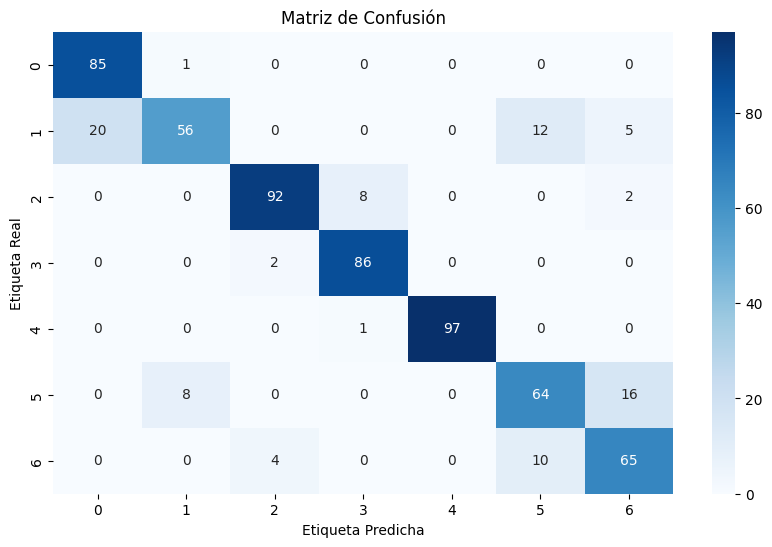

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.show()

---

## Pruebas Adicionales de Robustez

In [15]:
# Nueva celda al final del notebook
print("\n=== Pruebas de Robustez ===")
# Verificar manejo de datos faltantes
try:
    model.predict(np.full((1, X.shape[1]), np.nan))
    print("Advertencia: El modelo acepta valores NaN sin manejo explícito")
except Exception:
    print("El modelo rechaza valores NaN correctamente")

# Prueba de persistencia (guardar y cargar modelo)
from joblib import dump, load
try:
    dump(model, 'obesity_model.joblib')
    loaded_model = load('obesity_model.joblib')
    assert loaded_model.score(X_test, y_test) == accuracy
    print("Prueba de persistencia exitosa")
except Exception as e:
    print(f"Error en persistencia: {str(e)}")


=== Pruebas de Robustez ===
El modelo rechaza valores NaN correctamente
Prueba de persistencia exitosa
